In [1]:
%matplotlib inline

from matplotlib import pyplot as plt


import jax
from jax import numpy as jnp

from xxm.lds.core import Model, GaussianEmissions, Posterior
from xxm.lds.learning import fit_em_many
from xxm.lds import init



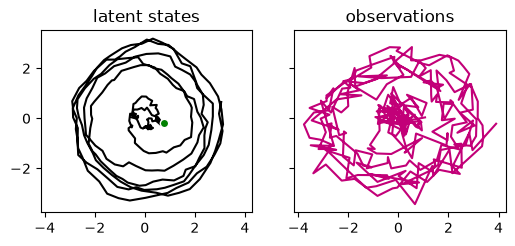

In [2]:
def make_rotating_lds(
    angle: float = 0.15,
    process_noise: float = 0.01,
    observation_noise: float = 0.1,
) -> Model:
    rotation = jnp.array([
        [jnp.cos(angle), -jnp.sin(angle)],
        [jnp.sin(angle),  jnp.cos(angle)],
    ])

    return Model(
        initial_mean=jnp.array([1.0, 0.0]),
        initial_covariance=0.01 * jnp.eye(2),
        dynamics_matrix=rotation,
        dynamics_bias=jnp.zeros(2),
        dynamics_noise_covariance=process_noise * jnp.eye(2),
        emissions=GaussianEmissions(
            readout=jnp.array([
                [1.0, 0.5],
                [-0.3, 0.8],
            ]),
            bias=jnp.zeros(2),
            noise_covariance=observation_noise * jnp.eye(2),
        ),
    )


true_model = make_rotating_lds()

states, observations = true_model.sample(
    num_steps=300,
    key=jax.random.key(0),
)


def plot_data(states, observations):

    f, axs = plt.subplots(ncols=2, figsize=(6, 4), sharex=True, sharey=True)

    ax = axs[0]
    ax.plot(states[:, 0], states[:, 1], color='k')
    ax.set(title="latent states", aspect='equal')
    ax.scatter(states[0, 0], states[0, 1], edgecolor='w', facecolor='green', label='start', zorder=10)

    ax = axs[1]
    ax.plot(observations[:, 0], observations[:, 1], color='xkcd:magenta')
    ax.set(title="observations", aspect='equal')


plot_data(states, observations)

In [3]:
posterior = true_model.inference(observations)

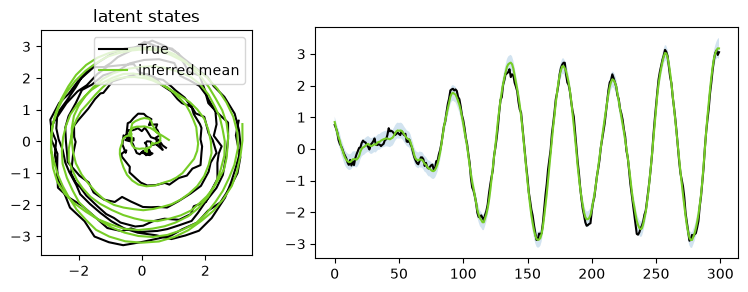

In [4]:
def plot_inference(states, posterior):
    f, axs = plt.subplots(ncols=2, gridspec_kw={'width_ratios': [1, 2]}, figsize=(9, 3))


    ax = axs[0]
    ax.plot(states[:, 0], states[:, 1], label="True", color='k')
    ax.plot(
        posterior.means[:, 0],
        posterior.means[:, 1],
        label="inferred mean",
        color='xkcd:apple green',
    )

    ax.set(
        title="latent states", aspect='equal',
    )

    ax.legend(loc='upper right')

    ax = axs[1]

    std = jnp.sqrt(posterior.covariances[:, 0, 0])

    ax.plot(states[:, 0], label="true", color='k')
    ax.plot(posterior.means[:, 0], label="posterior", color='xkcd:apple green')
    ax.fill_between(
        jnp.arange(len(states)),
        posterior.means[:, 0] - 2 * std,
        posterior.means[:, 0] + 2 * std,
        alpha=0.2,
    )

plot_inference(states, posterior)

''

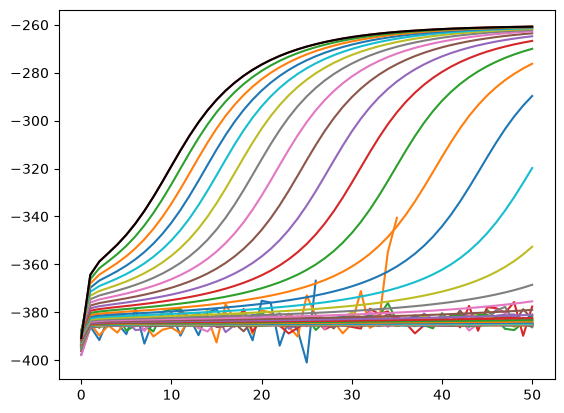

In [ ]:
initial_models = init.init_pca_many(observations, state_dim=2, covariance_floors=jnp.logspace(-5, -2, 64))


fits = fit_em_many(
    initial_models,
    observations,
    num_iters=50,
)


f, ax = plt.subplots()

ax.plot(fits.objective_traces.T)

best_idx = fits.best_index()

initial_model = initial_models[best_idx]

fitted_model, log_likelihoods = fits.get(best_idx)

ax.plot(log_likelihoods, color='k');


In [6]:
initial_posterior = initial_model.inference(observations)

fitted_posterior = fitted_model.inference(observations)

Text(0.5, 1.0, 'Fitted posterior')

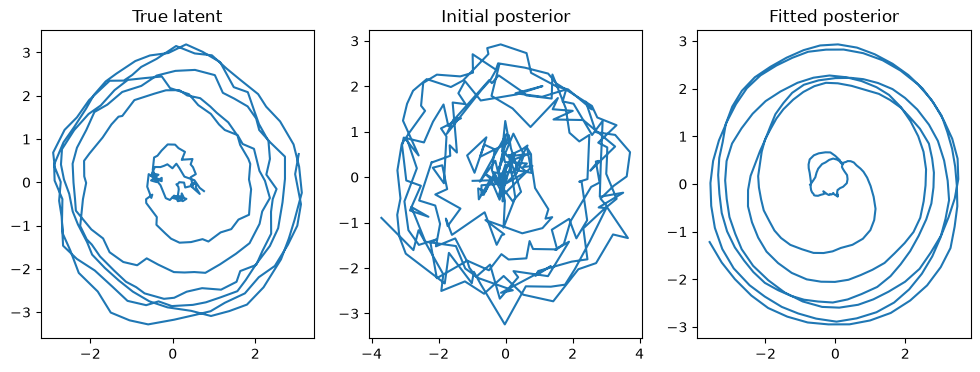

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(states[:, 0], states[:, 1])
axes[0].set_title("True latent")

axes[1].plot(
    initial_posterior.means[:, 0],
    initial_posterior.means[:, 1],
)
axes[1].set_title("Initial posterior")

axes[2].plot(
    fitted_posterior.means[:, 0],
    fitted_posterior.means[:, 1],
)
axes[2].set_title("Fitted posterior")

In [8]:
initial_prediction = (
    initial_posterior.means @ initial_model.emissions.readout.T
    + initial_model.emissions.bias
)

fitted_prediction = (
    fitted_posterior.means @ fitted_model.emissions.readout.T
    + fitted_model.emissions.bias
)

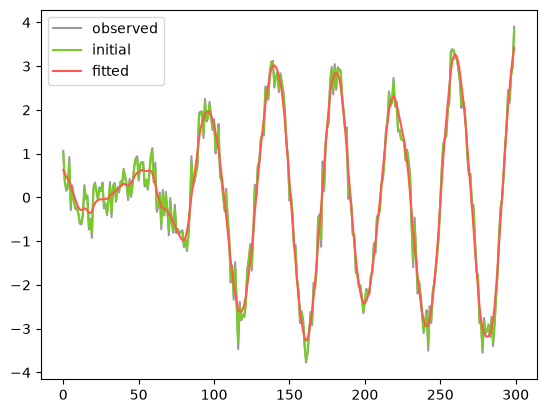

In [9]:
f, ax = plt.subplots()

ax.plot(observations[:, 0], alpha=0.4, label="observed", color='k')
ax.plot(initial_prediction[:, 0], label="initial", color='xkcd:apple green')
ax.plot(fitted_prediction[:, 0], label="fitted", color='xkcd:coral')
ax.legend()